# Análisis de Churn Bancario con Exploración de Datos y Generación de Insights mediante LLM

## Objetivo del Proyecto

El objetivo de este proyecto es combinar un análisis tradicional de datos con el uso de un modelo de lenguaje (LLM) para generar insights automáticos sobre el churn de clientes.\
Concretamente, buscamos que el LLM:

* Interprete estadísticas clave del dataset.
* Genere explicaciones sobre posibles factores que influyen en el churn.
* Proponga hipótesis y recomendaciones basadas en los datos.
* Transforme la información técnica en insights comprensibles para negocio.

## Descripción del Dataset

El dataset contiene información sobre clientes de una entidad bancaria y su comportamiento en relación con el abandono del servicio (churn). Cada fila representa un cliente y contiene variables demográficas, financieras y de comportamiento.

| Variable | Descripción |
|--------|-------------|
| customer_id | Identificador único del cliente |
| surname | Apellido del cliente |
| credit_score | Puntaje crediticio que refleja la solvencia financiera del cliente |
| geography | País de residencia del cliente |
| gender | Género del cliente |
| age | Edad del cliente |
| tenure | Años del depósito a plazo fijo |
| balance | Saldo disponible en la cuenta bancaria |
| num_of_products | Número de productos contratados por el cliente |
| has_cr_card | Indica si el cliente posee tarjeta de crédito (1 = sí, 0 = no) |
| is_active_member | Indica si el cliente es un miembro activo (1 = sí, 0 = no) |
| estimated_salary | Salario estimado del cliente |
| exited | Variable objetivo: indica si el cliente abandonó el banco (1 = sí, 0 = no) |

## 1. Inicialización

In [1]:
import pandas as pd
import numpy as np

import re

from openai import OpenAI

## 2. Carga de Datos

In [2]:
data = pd.read_csv('dataset/churn.csv')

## 3. Visualización inicial

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


In [4]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [5]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Las columna contienen datos con el tipo correcto, tenemos valores nulos únicamente en la columna 'tenure', sin embargo esta columna representa no solo un tiempo si no tambien si el usuario tiene este servicio. En nuestro caso no podemos suponer que un 'tenure' faltante significa que el usuario no posee el servicio, tambien podria indicar que simplemente no tenemos la información disponible aún. Veremos más adelante como tratar nuestros nulos.

Los datos en general son coherentes, aunque un usuario tenga un balance de 0 o un 'tenure' de 0, todos los usuarios tienen al menos un producto con el banco, así mismo usuarios nuevos pueden no presentar información en los campos de productos pero tener al menos uno de ellos.

## 4. Preparación y limpieza de datos

### 4.1 Conversión de columnas a tipo snake

In [6]:
column_names = []

for name in data.columns:
    snaked_name1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    snaked_name2 = re.sub('([a-z])([A-Z])', r'\1_\2', snaked_name1)
    snaked_name2 = snaked_name2.lower()
    column_names.append(snaked_name2)

data.columns = column_names
data.columns

Index(['row_number', 'customer_id', 'surname', 'credit_score', 'geography',
       'gender', 'age', 'tenure', 'balance', 'num_of_products', 'has_cr_card',
       'is_active_member', 'estimated_salary', 'exited'],
      dtype='str')

### 4.2 Revisión de valores nulos

Inicialmente verificaremos si los valores nulos, encontrados unicamente en 'tenure' tienen algún impacto en el objetivo.

In [7]:
print('Media de abandono usuarios con tenure nulo:', data[data['tenure'].isna()]['exited'].mean())
print('Media de abandono usuarios con tenure No nulo:', data[data['tenure'].notna()]['exited'].mean())

Media de abandono usuarios con tenure nulo: 0.20132013201320131
Media de abandono usuarios con tenure No nulo: 0.2039379606203938


Ya que claramente no hay un impacto importante en generado por los valores nulos reemplazaremos estos valores por la media o mediana:

In [8]:
data['tenure'].describe()

count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: tenure, dtype: float64

Ya que en nuestro caso la media y mediana son casi iguales utilizaremos la mediana.

In [9]:
data['tenure'] = data['tenure'].fillna(data['tenure'].median())
data['tenure'].isna().sum()

np.int64(0)

### 4.3 Verificación de duplicados

In [10]:
print('Filas completamente duplicadas:', data.duplicated().sum())

Filas completamente duplicadas: 0


In [11]:
print('Ids duplicados:', data['customer_id'].duplicated().sum())

Ids duplicados: 0


### 4.4 Eliminar columna row_number

Nuestra columna 'row_number' no aporta información importante para nuestro análisis así que procederemos a eliminarla

In [12]:
data = data.drop(['row_number'], axis=1)
data.columns

Index(['customer_id', 'surname', 'credit_score', 'geography', 'gender', 'age',
       'tenure', 'balance', 'num_of_products', 'has_cr_card',
       'is_active_member', 'estimated_salary', 'exited'],
      dtype='str')

## 5. Diccionario de columnas

Crearemos un diccionario donde se especificará de manera resumida el significado de los valores de cada columna.

In [13]:
column_descriptions = {
    'customer_id': 'Identificador único del cliente. No aporta información predictiva directa.',
    'surname': 'Apellido del cliente. Variable categórica sin impacto directo en churn.',
    'credit_score': 'Puntaje crediticio del cliente. Valores más bajos suelen indicar mayor riesgo.',
    'geography': 'País de origen del cliente. Captura diferencias económicas o culturales.',
    'gender': 'Género del cliente: Male o Female.',
    'age': 'Edad del cliente en años. Importante por su relación con la estabilidad financiera.',
    'tenure': 'Años que el cliente ha permanecido con un depósito fijo en la empresa.',
    'balance': 'Saldo del cliente en la cuenta bancaria.',
    'num_of_products': 'Número de productos contratados por el cliente.',
    'has_cr_card': 'Indica si tiene tarjeta de crédito (1 = sí, 0 = no).',
    'is_active_member': 'Cliente activo en la empresa (1 = activo, 0 = no activo).',
    'estimated_salary': 'Salario estimado del cliente.',
    'exited': 'Objetivo: indica si el cliente abandonó (1) o no (0).'
}

### 6. Resumen estadístico detallado

Generemos ahora una tabla con el resumén estadístico de nuestro dataset limpio.

In [14]:
summary_stats = data.describe(include='all').transpose()
summary_stats

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
tenure,10000.0,NaN,NaN,NaN,4.9979,2.76001,0.0,3.0,5.0,7.0,10.0
balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
num_of_products,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0
has_cr_card,10000.0,NaN,NaN,NaN,0.7055,0.45584,0.0,0.0,1.0,1.0,1.0


## 7. Conversión de estadísticas a texto

Es necesaria esta conversión para que LLM pueda interpretarlo. Para esto crearemos una función que cree textos a partir de las descripciones de cada columna creadas anteriormente y de nuestros datos estadísticos.

In [15]:
def build_llm_friendly_summary(data, column_descriptions, summary_stats):
    summary_text = ''
    for column in data.columns:
        summary_text += f'\nVariable: {column}\n'
        summary_text += f"Descripción: {column_descriptions.get(column, 'Sin descripción disponible.')}\n"
    
        if column in summary_stats.index:
            stats = summary_stats.loc[column]
        
            # Agregar estadísticas relevantes si están disponibles
            if 'mean' in stats:
                summary_text += f"Media: {stats['mean']:.2f}\n"
            if 'min' in stats:
                summary_text += f"Mínimo: {stats['min']}\n"
            if 'max' in stats:
                summary_text += f"Máximo: {stats['max']}\n"
            if 'unique' in stats:
                summary_text += f"Valores únicos: {stats['unique']}\n"
            if 'top' in stats:
                summary_text += f"Valor más frecuente: {stats['top']}\n"
            if 'freq' in stats:
                summary_text += f"Frecuencia del más común: {stats['freq']}\n"
        
        summary_text += '-----------------------------\n'
    return summary_text

llm_ready_text = build_llm_friendly_summary(data, column_descriptions, summary_stats)

print(llm_ready_text[:1000])


Variable: customer_id
Descripción: Identificador único del cliente. No aporta información predictiva directa.
Media: 15690940.57
Mínimo: 15565701.0
Máximo: 15815690.0
Valores únicos: nan
Valor más frecuente: nan
Frecuencia del más común: nan
-----------------------------

Variable: surname
Descripción: Apellido del cliente. Variable categórica sin impacto directo en churn.
Media: nan
Mínimo: nan
Máximo: nan
Valores únicos: 2932
Valor más frecuente: Smith
Frecuencia del más común: 32
-----------------------------

Variable: credit_score
Descripción: Puntaje crediticio del cliente. Valores más bajos suelen indicar mayor riesgo.
Media: 650.53
Mínimo: 350.0
Máximo: 850.0
Valores únicos: nan
Valor más frecuente: nan
Frecuencia del más común: nan
-----------------------------

Variable: geography
Descripción: País de origen del cliente. Captura diferencias económicas o culturales.
Media: nan
Mínimo: nan
Máximo: nan
Valores únicos: 3
Valor más frecuente: France
Frecuencia del más común: 5014

## 8. Prompt inicial

In [16]:
prompt = f'''
Eres un analista de datos experto en churn. A continuación recibirás un resumen estructurado
sobre un dataset ya limpiado que contiene información de clientes bancarios. Tu tarea es:

1. Identificar posibles factores que influyen en el churn (columna 'exited').
2. Explicar por qué esos factores pueden estar relacionados con el abandono.
3. Generar hipótesis basadas en patrones numéricos o categóricos.
4. Indicar qué variables parecen más relevantes.
5. Señalar cualquier tendencia notable en los datos.

IMPORTANTE:
- No inventes datos. Basa tus conclusiones únicamente en la información proporcionada.
- Interpreta los valores numéricos como magnitudes reales (edad, balance, salario, productos).
- Considera que 1 = verdadero y 0 = falso en las variables binarias.

Aquí tienes la descripción del dataset:

{llm_ready_text}
'''

## 9. LLamar inicial LLM. Análisis inicial general

In [17]:
client = OpenAI(api_key='')

try:
    response = client.chat.completions.create(
        model='gpt-4.1',
        messages=[
            {'role': 'system', 'content': 'Eres un analista de datos experto en churn.'},
            {'role': 'user', 'content': prompt}
        ]
    )

    # Guardamos la respuesta del modelo
    llm_insights = response.choices[0].message.content

    # Mostramos la respuesta en pantalla
    print(llm_insights)

    # Guardamos la respuesta en un archivo
    with open('llm_insights_churn.txt', 'w', encoding='utf-8') as f:
        f.write(llm_insights)

    print('Insights guardados correctamente en llm_insights_churn.txt')

except Exception as e:
    print('Error al llamar al modelo:', e)

Claro, con base en la información proporcionada sobre el dataset, a continuación te presento el análisis solicitado para identificar los factores que podrían influir en el churn, así como las hipótesis y tendencias relevantes:

---

### 1. **Posibles factores que influyen en el churn ('exited')**

#### Variables que por su naturaleza son más propensas a estar relacionadas con churn:

- **credit_score** (puntaje crediticio)
- **geography** (país)
- **gender** (género)
- **age** (edad)
- **tenure** (años de permanencia)
- **balance** (saldo bancario)
- **num_of_products** (número de productos contratados)
- **has_cr_card** (posee tarjeta de crédito)
- **is_active_member** (nivel de actividad)
- **estimated_salary** (salario estimado)

---

### 2. **Explicación del posible vínculo entre esas variables y el abandono**

- **credit_score**: Clientes con menor puntaje suelen considerarse más riesgosos y pueden ser menos atractivos para el banco o experimentar dificultades financieras, lo que 

## 10. Análisis avanzado mediante LLM

### Análisis Estadístico Previo al Uso del LLM

Antes de utilizar el modelo de lenguaje, se calculan estadísticas agregadas del dataset con el objetivo de proporcionar información estructurada que el modelo pueda interpretar correctamente.

Los modelos de lenguaje no analizan directamente datos tabulares como lo haría un algoritmo de machine learning. En su lugar, interpretan información textual. Por esta razón, se construye un resumen estructurado que incluye:

- Descripción de las variables
- Estadísticas descriptivas
- Tasas de churn por categoría y por rangos numéricos

Este enfoque permite que el LLM identifique patrones relevantes y genere hipótesis interpretables desde una perspectiva de negocio.

### 10.1 Generación de estadísticas enfocadas al abandono por característica

In [25]:
def churn_by_column(data, column, bins=None):
    if bins is not None:
        # Para columnas numéricas: binning
        data['temp_bin'] = pd.cut(data[column], bins=bins)
        result = data.groupby('temp_bin')['exited'].mean() * 100
        data = data.drop(columns=['temp_bin'])
        return result
    else:
        # Para columnas categóricas
        return (data.groupby(column)['exited'].mean() * 100).sort_values(ascending=False)

# Diccionario donde guardaremos los análisis
churn_analysis = {}

# Columnas categóricas
categorical_cols = ['geography', 'gender', 'has_cr_card', 'is_active_member', 'num_of_products']
for col in categorical_cols:
    churn_analysis[col] = churn_by_column(data, col)

# Columnas numéricas (con binning inteligente)
numeric_cols = ['age', 'balance', 'estimated_salary', 'credit_score', 'tenure']
binning_rules = {
    'age': [0, 30, 50, 100],
    'balance': [-1, 50000, 100000, 250000],
    'estimated_salary': [0, 50000, 100000, 200000],
    'credit_score': [300, 500, 650, 850],
    'tenure': [-1, 2, 5, 10]
}

for col in numeric_cols:
    churn_analysis[col] = churn_by_column(data, col, bins=binning_rules[col])

print(churn_analysis)

{'geography': geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: exited, dtype: float64, 'gender': gender
Female    25.071539
Male      16.455928
Name: exited, dtype: float64, 'has_cr_card': has_cr_card
0    20.814941
1    20.184266
Name: exited, dtype: float64, 'is_active_member': is_active_member
0    26.850897
1    14.269074
Name: exited, dtype: float64, 'num_of_products': num_of_products
4    100.000000
3     82.706767
1     27.714398
2      7.581699
Name: exited, dtype: float64, 'age': temp_bin
(0, 30]       7.520325
(30, 50]     19.583518
(50, 100]    44.647105
Name: exited, dtype: float64, 'balance': temp_bin
(-1, 50000]         14.247021
(50000, 100000]     19.880716
(100000, 250000]    25.218841
Name: exited, dtype: float64, 'estimated_salary': temp_bin
(0, 50000]          19.934774
(50000, 100000]     19.865983
(100000, 200000]    20.838323
Name: exited, dtype: float64, 'credit_score': temp_bin
(300, 500]    23.639191
(500, 650]    21.075920
(650, 

### 10.2 Conversión estadísticas a texto 

Ya que un LLM no tiene la capacidad de interpretar números por si solo, requiere un contexto basado en texto, por tanto debemos convertir nuestros valores estadísticos en información que pueda ser interpretada por LLM.

In [29]:
def build_churn_analysis_text(churn_analysis):
    text = 'ANÁLISIS DETALLADO DE CHURN POR COLUMNA:\n'
    text += '--------------------------------------\n'

    for column, series in churn_analysis.items():
        text += f'Variable: {column}\n'
        text += 'Valores y tasas de churn:\n'

        for key, value in series.items():
            text += f'- {key}: {value:.2f}% \n'

        text += '-----------------------------\n'

    return text

churn_llm_text = build_churn_analysis_text(churn_analysis)

print(churn_llm_text[:1500])

ANÁLISIS DETALLADO DE CHURN POR COLUMNA:
--------------------------------------
Variable: geography
Valores y tasas de churn:
- Germany: 32.44% 
- Spain: 16.67% 
- France: 16.15% 
-----------------------------
Variable: gender
Valores y tasas de churn:
- Female: 25.07% 
- Male: 16.46% 
-----------------------------
Variable: has_cr_card
Valores y tasas de churn:
- 0: 20.81% 
- 1: 20.18% 
-----------------------------
Variable: is_active_member
Valores y tasas de churn:
- 0: 26.85% 
- 1: 14.27% 
-----------------------------
Variable: num_of_products
Valores y tasas de churn:
- 4: 100.00% 
- 3: 82.71% 
- 1: 27.71% 
- 2: 7.58% 
-----------------------------
Variable: age
Valores y tasas de churn:
- (0, 30]: 7.52% 
- (30, 50]: 19.58% 
- (50, 100]: 44.65% 
-----------------------------
Variable: balance
Valores y tasas de churn:
- (-1, 50000]: 14.25% 
- (50000, 100000]: 19.88% 
- (100000, 250000]: 25.22% 
-----------------------------
Variable: estimated_salary
Valores y tasas de churn:
- 

### 10.3 Creación de prompt

Constriremos un prompt que le permita a nuestro modelo entender el contexto, objetivo y limitaciones sobre las que debe trabajar y generar insights descriptivos basado en nuestros datos con el fin de encontrar los segmentos mas propensos al abandono. Esta información permitiria construir campañas de retención basadas además en características propias de comportamiento de sectores poblacionales. 

In [30]:
eda_prompt = f"""
Eres un analista senior especializado en abandono de clientes (churn) y comportamiento financiero.
Tu tarea es analizar profundamente un dataset bancario ya procesado y con estadísticas reales.

Recibirás dos bloques de información:
1) Descripción del dataset y estadísticas generales.
2) Tasas REALES de churn por categoría y por rangos numéricos.

Con esta información debes producir un análisis extremadamente profundo y accionable.

### TU OBJETIVO ES:
- Identificar patrones reales que expliquen el churn.
- Comparar segmentos y explicar por qué presentan más o menos abandono.
- Encontrar interacciones entre variables (edad + país, salario + actividad, etc.).
- Detectar segmentos críticos de alto riesgo.
- Señalar segmentos inesperados o anómalos.
- Identificar posibles causas operativas o de negocio.
- Proponer recomendaciones basadas en los hallazgos.

### INSTRUCCIONES PARA EL ANÁLISIS:
- Usa exclusivamente los datos proporcionados.
- No inventes números ni categorías que no aparezcan explícitamente.
- Puedes realizar razonamientos basados en lógica de negocio.
- Considera el tamaño de las muestras (si un segmento es muy pequeño, indícalo).
- Prioriza los patrones fuertes y estadísticamente relevantes.
- Si encuentras relaciones combinadas interesantes, descríbelas.
- Entrega el análisis en forma estructurada y con conclusiones claras.

### BLOQUE 1: DESCRIPCIÓN GENERAL DEL DATASET
{llm_ready_text}

### BLOQUE 2: ANÁLISIS REAL DE CHURN POR COLUMNA
{churn_llm_text}

"""


### 10.4 Resultados LLM

In [32]:
try:
    response_advanced = client.chat.completions.create(
        model='gpt-4.1',
        messages=[
            {'role': 'system', 'content': 'Eres un analista de datos experto en churn.'},
            {'role': 'user', 'content': eda_prompt}
        ]
    )

    advanced_insights = response_advanced.choices[0].message.content
    print(advanced_insights)

    # Guardar insights avanzados en archivo
    with open('llm_advanced_insights_churn.txt', 'w', encoding='utf-8') as f:
        f.write(advanced_insights)

    print('Insights avanzados guardados en llm_advanced_insights_churn.txt')

except Exception as e:
    print('Error al llamar al modelo avanzado:', e)

# Análisis Profundo de Churn Bancario
---

## 1. Resumen Ejecutivo

El análisis revela varias variables críticas explicando el abandono (churn) de clientes. Destacan especialmente: país de residencia, edad, género, número de productos contratados, balance, actividad del cliente y ciertas interacciones entre estas variables. Se identifican segmentos de alto riesgo y algunos patrones inesperados/anómalos directamente accionables para estrategias de retención.

---

## 2. Análisis Variable por Variable

### a) **Geography**
- **Germany**: 32.44% (mucho mayor que el promedio general de ~20%).
- **France & Spain**: Ambas alrededor del 16% — están considerablemente por debajo de la media.

**Patrón:** Los clientes de Alemania abandonan el banco el doble que españoles o franceses.
- **Implica diferencia cultural o fallos operativos/locales importantes en Alemania.**

---

### b) **Gender**
- **Female**: 25.07%  
- **Male**: 16.46%

**Patrón:** Las mujeres muestran un churn significativamente 

## 11. Visualización y Validación de Insights de Churn

In [33]:
from matplotlib import pyplot as plt

### 11.1 Ubicación geográfica

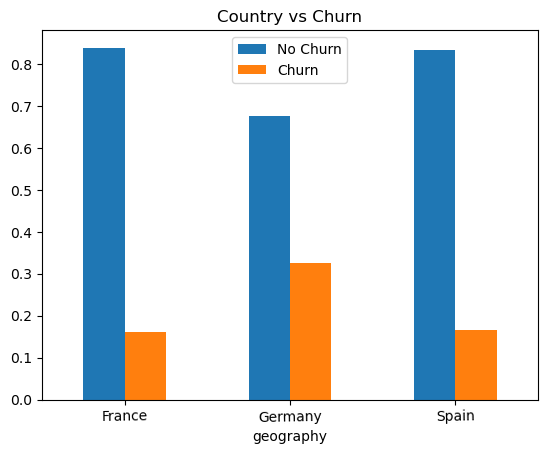

In [34]:
pd.crosstab(data['geography'], data['exited'], normalize='index').plot(kind='bar', rot=1, title='Country vs Churn')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [35]:
pd.crosstab(data['geography'], data['exited'], normalize='index')

exited,0,1
geography,,
France,0.838452,0.161548
Germany,0.675568,0.324432
Spain,0.833266,0.166734


Inicialmente podemos observar que en proporción los usuarios de origen alemán abandonan más, representando un 32% de los usuarios de esa región, muy por encima de la tasa de abandono en los otros dos paises que es aproximadamente de 16%. Es claramente una región cuyos usuarios son más propensos al abandono.

### 11.2 Género

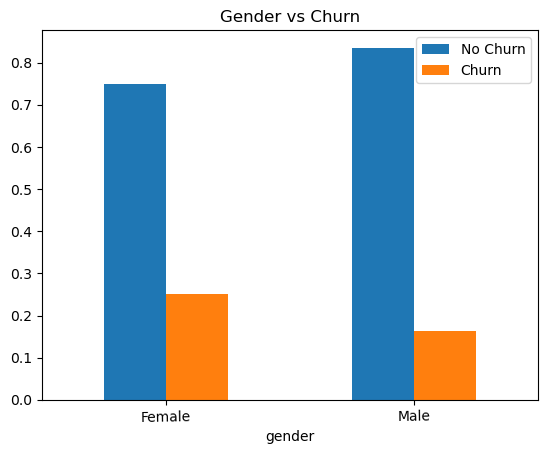

In [36]:
pd.crosstab(data['gender'], data['exited'], normalize='index').plot(kind='bar', rot=1, title='Gender vs Churn')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [37]:
pd.crosstab(data['gender'], data['exited'], normalize='index')

exited,0,1
gender,,
Female,0.749285,0.250715
Male,0.835441,0.164559


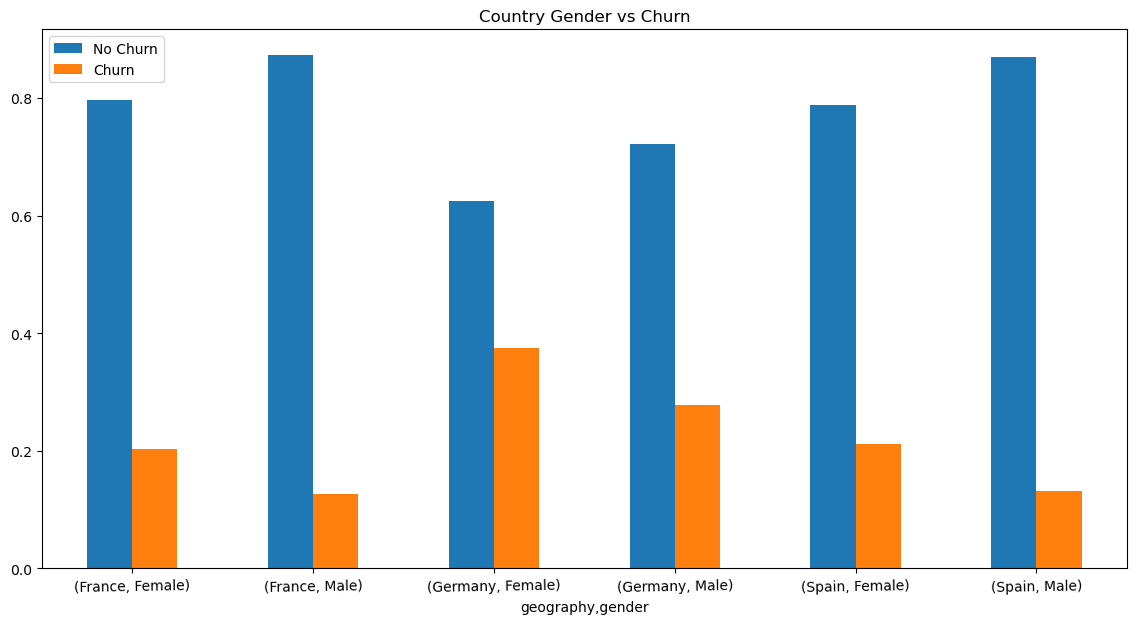

In [38]:
fig, ax = plt.subplots(figsize=(14, 7))
pd.crosstab([data['geography'], data['gender']], data['exited'], normalize='index').plot(kind='bar', rot=1, ax=ax, title='Country Gender vs Churn')

plt.legend(['No Churn', 'Churn'])
plt.show()

In [39]:
pd.crosstab([data['geography'], data['gender']], data['exited'], normalize='index')

exited                   0         1
geography gender                    
France    Female  0.796550  0.203450
          Male    0.872866  0.127134
Germany   Female  0.624476  0.375524
          Male    0.721884  0.278116
Spain     Female  0.787879  0.212121
          Male    0.868876  0.131124

Las mujeres presentan una tasa de abandono más alta, llegando al 25% en general, y cuando comparamos los datos por región se mántiene esta tendencia en cada país, siendo nuevamente Alemania el país con mayor tasa de abandono tnato en hombres como mujeres con un 27.8% de abandono para los hombres y un 37.5% para las mujeres. Números muy altos e importantes para esta población. 

### 11.3 Edad

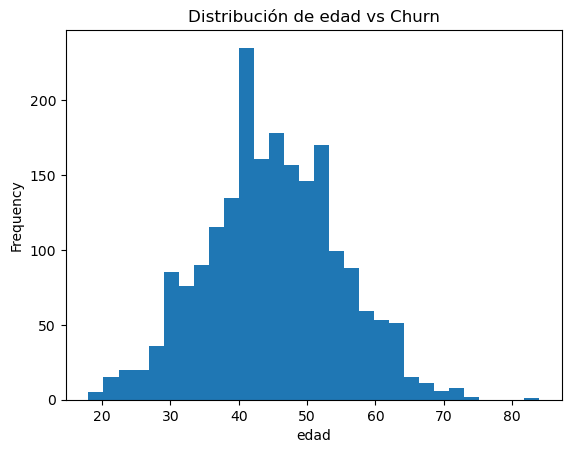

In [40]:
data[data['exited'] == 1]['age'].plot(kind='hist', bins=30, xlabel='edad', title='Distribución de edad vs Churn')
plt.show()

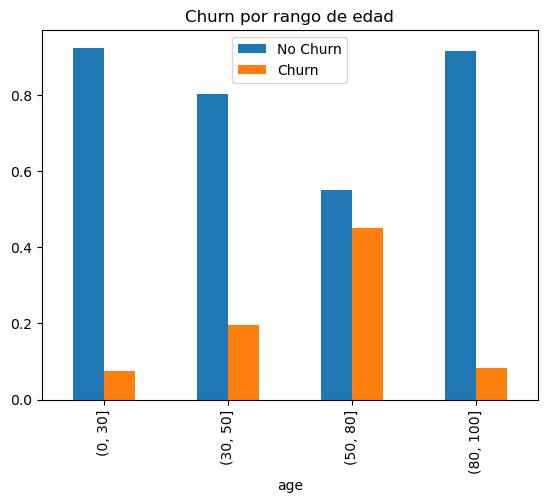

In [41]:
pd.crosstab(pd.cut(data['age'], bins=[0, 30, 50, 80, 100]),
            data['exited'],
            normalize='index').plot(kind='bar',
                                   title='Churn por rango de edad')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [42]:
pd.crosstab(pd.cut(data['age'], bins=[0, 30, 50, 80, 100]),
            data['exited'],
            normalize='index')

exited,0,1
age,,
"(0, 30]",0.924797,0.075203
"(30, 50]",0.804165,0.195835
"(50, 80]",0.550040,0.449960
"(80, 100]",0.916667,0.083333


Encontramos ahora que una población que presenta alto riesgo de abandonar el banco son personas mayores, entre 50 y 80 años de edad con una tasa de abandono de casi el 45%, seguida muy por debajo por personas con edades entre 30 y 50 años de edad. 

### 11.4 Tiempo de depósito a plazo fijo

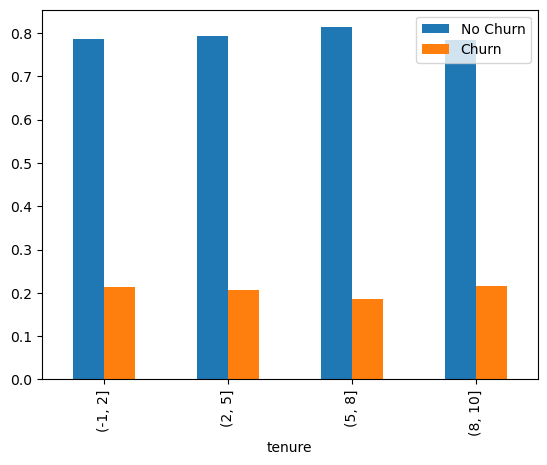

In [43]:
pd.crosstab(pd.cut(data['tenure'], bins=[-1, 2, 5, 8, 10]),
            data['exited'],
            normalize='index').plot(kind='bar')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [44]:
pd.crosstab(pd.cut(data['tenure'], bins=[-1, 2, 5, 8, 10]),
            data['exited'],
            normalize='index')

exited,0,1
tenure,,
"(-1, 2]",0.786340,0.213660
"(2, 5]",0.793916,0.206084
"(5, 8]",0.813436,0.186564
"(8, 10]",0.784639,0.215361


No se encuentra una tendencia fuerte o clara sobre un tiempo de depósito que influya en el abandono de usuarios.

### 11.5 Balance

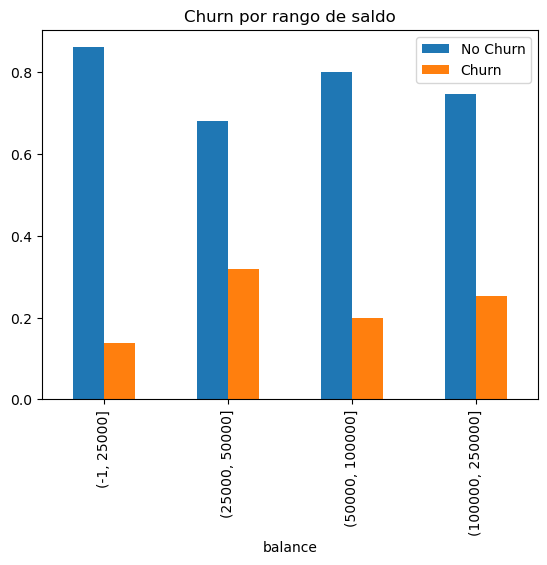

In [45]:
pd.crosstab(pd.cut(data['balance'], bins=[-1, 25000, 50000, 100000, 250000]),
            data['exited'],
            normalize='index').plot(kind='bar', title='Churn por rango de saldo')
plt.legend(['No Churn', 'Churn'])
plt.show()

In [46]:
pd.crosstab(pd.cut(data['balance'], bins=[-1, 25000, 50000, 100000, 250000]),
            data['exited'],
            normalize='index')

exited,0,1
balance,,
"(-1, 25000]",0.860889,0.139111
"(25000, 50000]",0.681159,0.318841
"(50000, 100000]",0.801193,0.198807
"(100000, 250000]",0.747812,0.252188


In [47]:
print('Número de clientes con saldo mayor a 100000:', (data['balance'] > 100000).sum())
print('Número de clientes con saldo entre 25000 y 50000:', ((data['balance'] > 25000) & (data['balance'] <= 50000)).sum())

Número de clientes con saldo mayor a 100000: 4799
Número de clientes con saldo entre 25000 y 50000: 69


Los usuarios con balances entre 25 mil y 50 mil dolares presentan la tasa más alta de abandono con un 31.8% seguidos por los usuarios con los balances más altos, aquellos con balances entre 100 mil y 250 mil dolares quiene spresentan una tasa de abando no de 25.2%, estos segundo representarían perdidas importantes teniendo en cuenta que nuestros datos indican que alrededor de 4799 usuarios se encuentran en ese rango de balance mientras que los primeros aunque con mayor abandono apenas representaban 69 usuarios. 

Esta población con altos balances presentan un riesgo imporante a evaluar especialmente por el alto impacto económico que puede generar la perdida de estos clientes al banco.

### 11.6 Número de productos

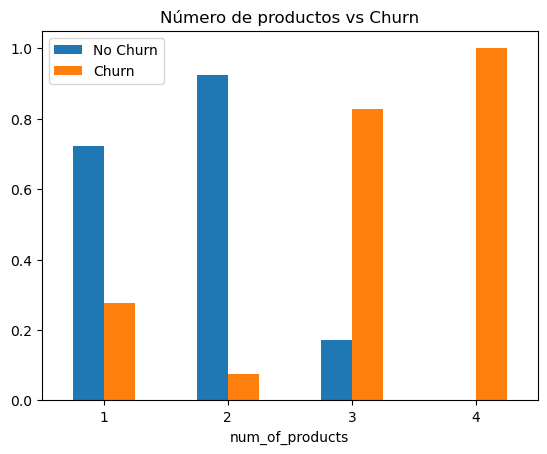

exited,0,1
num_of_products,,
1,0.722856,0.277144
2,0.924183,0.075817
3,0.172932,0.827068
4,0.000000,1.000000


In [48]:
pd.crosstab(data['num_of_products'], data['exited'], normalize='index').plot(kind='bar', rot=1, title='Número de productos vs Churn')
plt.legend(['No Churn', 'Churn'])
plt.show()

pd.crosstab(data['num_of_products'], data['exited'], normalize='index')

In [49]:
pd.crosstab([pd.cut(data['age'], bins=[0, 30, 50, 80, 100]), data['num_of_products']], data['exited'], normalize='index')

exited                            0         1
age       num_of_products                    
(0, 30]   1                0.891209  0.108791
          2                0.972683  0.027317
          3                0.387097  0.612903
          4                0.000000  1.000000
(30, 50]  1                0.732555  0.267445
          2                0.928161  0.071839
          3                0.169591  0.830409
          4                0.000000  1.000000
(50, 80]  1                0.471774  0.528226
          2                0.776995  0.223005
          3                0.078125  0.921875
          4                0.000000  1.000000
(80, 100] 1                0.800000  0.200000
          2                1.000000  0.000000

In [50]:
pd.crosstab(pd.cut(data['age'], bins=[0, 30, 50, 80, 100]), data['num_of_products'], normalize='index')

num_of_products,1,2,3,4
age,,,,
"(0, 30]",0.462398,0.520833,0.015752,0.001016
"(30, 50]",0.505834,0.462561,0.025255,0.006351
"(50, 80]",0.595677,0.341073,0.051241,0.012010
"(80, 100]",0.416667,0.583333,0.000000,0.000000


Vemos que el número de productos que un usuario posee con el banco tambien tiene alta influencia en el abandono, especialmente los usuarios con 3 productos muestra una alta tasa de abandono con un 82.7% seguido por usuarios con un solo producto con un abandono de 27.7%. Sin embargo cuando analisamos nuestros datos por grupos de edad vemos que son pocos los usuarios de cada grupo con 3 productos o más, pero se mantiene que la tasa de abandono más alta se presenta en personas mayores de 50 años con un 92% para personas de este grupo con 3 productos y un 52.8% de abandono para personas del mismo grupo de edad con 1 solo producto, estos valores cobran importancia cuando vemos que el 59.5% de este grupo tiene 1 producto.

Los usuarios con 4 productos presentan una tasa de abandono del 100%, ya que claramente es anómalo encontrar estos valores requeririamos más información por parte del banco sobre como debe interpretarse realmente este valor.

### 11.7 Actividad 

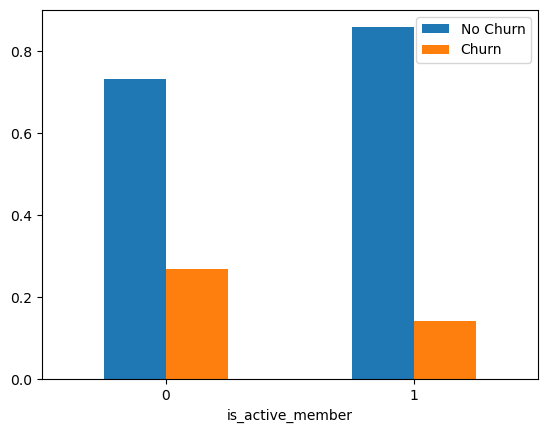

exited,0,1
is_active_member,,
0,0.731491,0.268509
1,0.857309,0.142691


In [51]:
pd.crosstab(data['is_active_member'], data['exited'], normalize='index').plot(kind='bar', rot=1)
plt.legend(['No Churn', 'Churn'])
plt.show()

pd.crosstab(data['is_active_member'], data['exited'], normalize='index')

La actividad continua de un usuario con la entidad bancaria tiene un efecto positivo, vemos que usuarios no activos presentan una tasa de abandono de 26.8% mientras que en los usuarios activos es de 14.2%. Es importante tener esto en cuenta para el diseño de campañas de retención así como en los servicios de atención a los usuarios.

### 11.8 Salario

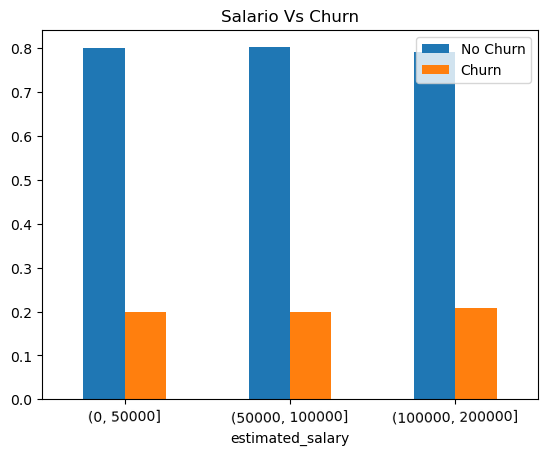

exited,0,1
estimated_salary,,
"(0, 50000]",0.800652,0.199348
"(50000, 100000]",0.801340,0.198660
"(100000, 200000]",0.791617,0.208383


In [52]:
pd.crosstab(pd.cut(data['estimated_salary'], bins=[0, 50000, 100000, 200000]), data['exited'], normalize='index').plot(kind='bar', rot=1, title='Salario Vs Churn')
plt.legend(['No Churn', 'Churn'])
plt.show()

pd.crosstab(pd.cut(data['estimated_salary'], bins=[0, 50000, 100000, 200000]), data['exited'], normalize='index')

No se presenta una tendencia clara al abandono que dependa directamente de los salarios de los usuarios.

### 11.9 Tarjeta de crédito

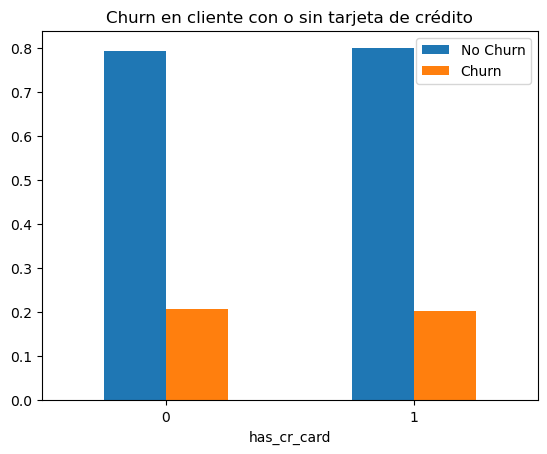

exited,0,1
has_cr_card,,
0,0.791851,0.208149
1,0.798157,0.201843


In [53]:
pd.crosstab(data['has_cr_card'], data['exited'], normalize='index').plot(kind='bar', rot=1, title='Churn en cliente con o sin tarjeta de crédito')
plt.legend(['No Churn', 'Churn'])
plt.show()

pd.crosstab(data['has_cr_card'], data['exited'], normalize='index')

La tenencia o no de una tarjeta de crédito no parece influenciar el abandono en los clientes.

### 11.10 Credit Score

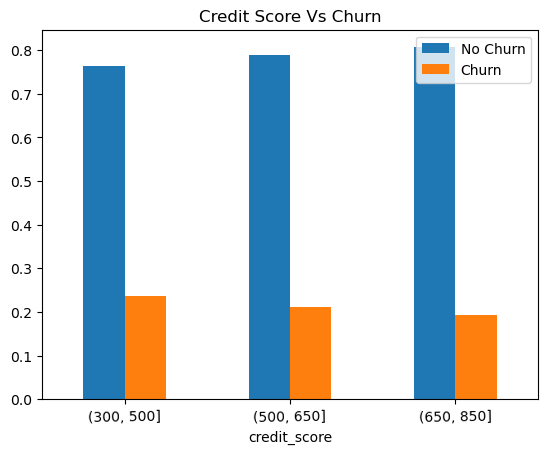

exited,0,1
credit_score,,
"(300, 500]",0.763608,0.236392
"(500, 650]",0.789241,0.210759
"(650, 850]",0.806439,0.193561


In [54]:
pd.crosstab(pd.cut(data['credit_score'], bins=[300, 500, 650, 850]), data['exited'], normalize='index').plot(kind='bar', rot=1, title='Credit Score Vs Churn')
plt.legend(['No Churn', 'Churn'])
plt.show()

pd.crosstab(pd.cut(data['credit_score'], bins=[300, 500, 650, 850]), data['exited'], normalize='index')

Existe una tendencia ligera pero visible en usuarios con menor calificación crediticia al abandono con una tasa del 23.6%, esta tasa parece disminuir al aumentar la calificación de los usuarios hasta un 19.3% en usuarios con valoración entre 650 y 850.

## 12. Resultados

Nuestro modelo LLM ha logrado realizar un análisis acertado en la mayoria de las conclusiones que encontró, fué capaz de distinguir los grupos poblacionales con mayor tasa de abandono al igual que correlacionarlos para encontrar los grupos con mayor riesgo de abandonar nuestro banco, dando como resultado que lus usuarios de Alemania, las personas mayores de 50 años y las mujeres con más propensos al abandono, y si combinamos estas caracteristicas obtenemos usuarios con riesgo inminente. Así mismo usuarios con balances altos mostraros alta tasa de abandono y considerando la cantidad de usuarios con esta característica podemos asegurar que representan tambien una prioridad de cara a campañas de retención. Usuarios con 3 productos se encuentran tambien en riesgo al igual que aquellos con bajo puntaje crediticio.

Por otra parte encontramos que aunque el modelo LLM tomó la columna 'tenure' como tiempo total del usuario con el banco y no como el tiempo del depósito a plazo fijo, afortunadamente en este caso estos valores no influyeron directamente ya que no se encontró una tendencia clara de estos valores a influir en el abandono.

Podemos decir entonces que el modelo LLM mostró gran capacidad de análisis, presentó factores claves a tener en cuenta y generó recomendaciones razonablesde cara a futuras campañas de retención. Al mismo tiempo podemos concluir que nuestro prompt logró indicar correctamente al LLM aquello que debia buscar e interpretar.

## 13. Limitaciones del Análisis

Aunque este proyecto permite explorar patrones relevantes relacionados con el churn utilizando tanto análisis estadístico como generación de insights mediante un LLM, existen algunas limitaciones que deben considerarse:

- El modelo de lenguaje no analiza directamente los datos originales, sino un resumen estadístico estructurado. Esto puede limitar su capacidad para detectar interacciones complejas entre variables.

- Algunos segmentos del dataset contienen un número reducido de observaciones, lo que puede generar tasas de churn extremas que deben interpretarse con cautela.

- El análisis generado por el LLM debe considerarse como una herramienta de apoyo para la interpretación de los datos, y no como un sustituto del análisis estadístico o del modelado predictivo.

- Este proyecto se centra en análisis exploratorio e interpretación de patrones, por lo que no incluye la construcción de un modelo predictivo de churn.

## 14. Conclusión

Este proyecto demuestra cómo los modelos de lenguaje pueden complementar el análisis tradicional de datos, facilitando la generación de hipótesis y la interpretación de patrones relevantes en el comportamiento de los clientes.

La combinación de análisis estadístico, visualización de datos y generación de insights mediante LLM permite explorar el problema del churn desde una perspectiva analítica y de negocio.